# **EDA Notebook**



---
## 0. Setup Environment

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 53.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data


---
## Student Information

In [ ]:
group_name = "Group 11"
student_name = "Rose Marie Tazbaz"
student_id = "25742507"

In [ ]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [ ]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [ ]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [ ]:
# <Student to fill this section>

### 0.b Import Packages

In [ ]:
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## B. Data Understanding

In [ ]:
# Do not modify this code
try:
  df = pd.read_csv(at.folder_path / "product_sub_category.csv")
except Exception as e:
  print(e)

### B.1 Explore Dataset

In [ ]:
df.shape
df.head()
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   product_subcategory_id  37 non-null     object
 1   product_category_id     37 non-null     object
 2   name                    37 non-null     object
dtypes: object(3)
memory usage: 1020.0+ bytes


,0
product_subcategory_id,0
product_category_id,0
name,0


In [ ]:
dataset_insights = "The dataset product_sub_category includes 37 observations and 3 categorical columns representing classifications of product subcategories and their connection to the broader product category. This dataset serves mainly as a reference database facilitating hierarchical classifications of products. There are no missing values found in any column, which reflects good data quality. The dataset’s simplicity and clarity indicate proper maintenance and its readiness to be included in more complex databases containing sales transactions and product information. From the business standpoint, product subcategories can serve as informative context about the customers’ purchase behavior, pricing strategies, and operation peculiarities of various product groups. In terms of anomaly detection, product subcategories can serve as useful context to discern typical from abnormal behavior regarding sales transactions. While the dataset doesn’t include transactional or numerical variables, it is assumed to become a valuable categorical context in further analysis phases, especially when checking whether the anomalous sales orders are clustered within certain product subcategories."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.2 Explore Feature of Interest `name`

In [ ]:
print(
    "Unique subcategories:",
    df['name'].nunique()
)

Unique subcategories: 37


In [ ]:
subcategory_counts = (
    df['name']
    .value_counts()
)

print(subcategory_counts)

name
Mountain Bikes       1
Road Bikes           1
Touring Bikes        1
Handlebars           1
Bottom Brackets      1
Brakes               1
Chains               1
Cranksets            1
Derailleurs          1
Forks                1
Headsets             1
Mountain Frames      1
Pedals               1
Road Frames          1
Saddles              1
Touring Frames       1
Wheels               1
Bib-Shorts           1
Caps                 1
Gloves               1
Jerseys              1
Shorts               1
Socks                1
Tights               1
Vests                1
Bike Racks           1
Bike Stands          1
Bottles and Cages    1
Cleaners             1
Fenders              1
Helmets              1
Hydration Packs      1
Lights               1
Locks                1
Panniers             1
Pumps                1
Tires and Tubes      1
Name: count, dtype: int64


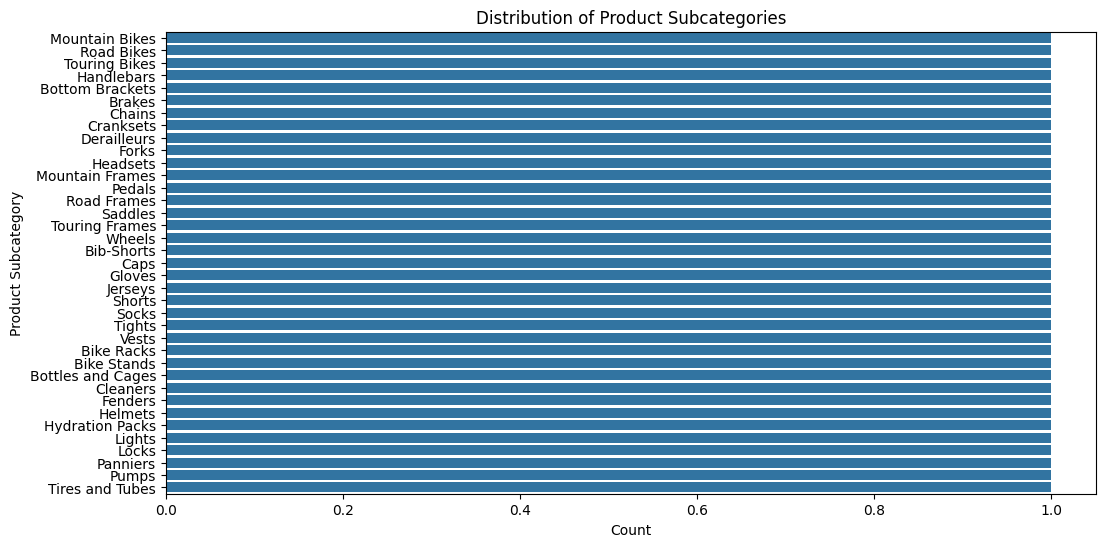

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df['name'],
    order=df['name'].value_counts().index
)

plt.title('Distribution of Product Subcategories')
plt.xlabel('Count')
plt.ylabel('Product Subcategory')

plt.show()

In [ ]:
feature_1_insights = "The name feature within the product_sub_category dataset contains 37 unique product subcategories, with each subcategory appearing exactly once. This confirms that the dataset functions as a clean hierarchical reference table with no duplicated category records or observable classification inconsistencies. The subcategories represent a diverse range of product groups, including bicycles, accessories, clothing items, mechanical components, and maintenance products. This hierarchical structure provides important contextual business information that may help explain variations in pricing, purchasing behaviour, inventory requirements, and transactional patterns across different product types. From a data quality perspective, the absence of duplicated or missing subcategory names indicates strong consistency and reliability within the classification structure. This is particularly important for ensuring accurate joins and category mapping during preprocessing and feature engineering stages. Within the context of anomaly detection, product subcategories are expected to provide valuable contextual information because purchasing behaviour can vary substantially across different product groups. For example, unusually large or expensive orders may be considered normal for certain high-value subcategories such as bicycles, while similar transactions may appear anomalous for smaller accessory or maintenance-related categories. One limitation of this feature is that the dataset itself does not contain transactional frequency information or quantitative measures associated with each subcategory. As a result, the feature’s analytical value will primarily emerge when integrated with larger transactional and product-level datasets during later modelling stages."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### B.3 Explore Feature of Interest `product_category_id`

In [ ]:
print(
    "Unique product categories:",
    df['product_category_id'].nunique()
)

Unique product categories: 4


In [ ]:
category_counts = (
    df['product_category_id']
    .value_counts()
)

print(category_counts)

product_category_id
65e2841b-c7da-4c4a-9565-cd8cfd9a2f68    14
0a37a9c4-764e-4952-bf4f-d47b38694c4d    12
2664e8d8-c7ce-4a38-aae4-07e0b536bba3     8
6b440a50-1a1b-4d3b-988f-076c498bd092     3
Name: count, dtype: int64


In [ ]:
category_percentage = (
    df['product_category_id']
    .value_counts(normalize=True) * 100
)

print(category_percentage)

product_category_id
65e2841b-c7da-4c4a-9565-cd8cfd9a2f68    37.837838
0a37a9c4-764e-4952-bf4f-d47b38694c4d    32.432432
2664e8d8-c7ce-4a38-aae4-07e0b536bba3    21.621622
6b440a50-1a1b-4d3b-988f-076c498bd092     8.108108
Name: proportion, dtype: float64


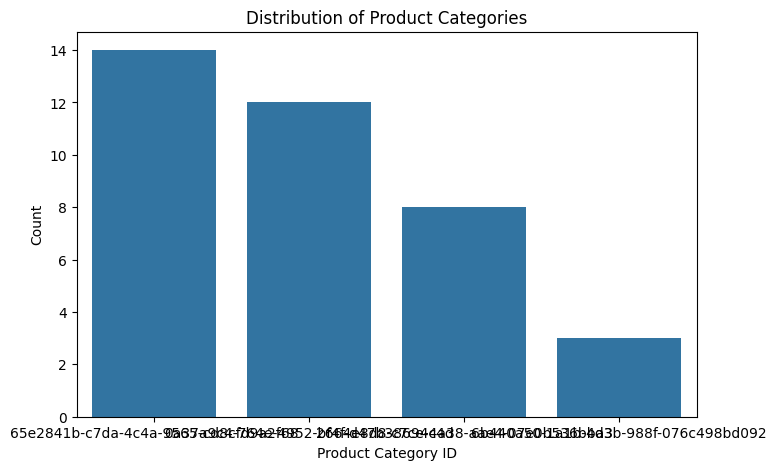

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df['product_category_id'],
    order=df['product_category_id'].value_counts().index
)

plt.title('Distribution of Product Categories')
plt.xlabel('Product Category ID')
plt.ylabel('Count')

plt.show()

In [ ]:
feature_2_insights = "The product_category_id feature reveals that the retailer’s product portfolio is organised into 4 main product categories, which collectively contain 37 product subcategories. This hierarchical structure suggests a relatively consolidated and well-organised product classification system. The distribution of subcategories across product categories is uneven, with the largest category accounting for approximately 37.84% of all subcategories, while the smallest represents only 8.11%. This imbalance indicates that certain business areas contain a broader diversity of products and may therefore generate more varied transactional behaviour and purchasing patterns. From a business perspective, different product categories are likely to exhibit substantially different pricing structures, inventory characteristics, customer demand patterns, and operational requirements. Consequently, sales behaviours considered unusual within one category may be entirely normal within another. Within the context of anomaly detection, category-level information is expected to provide important contextual support for interpreting unusual sales orders, abnormal purchasing behaviour, and pricing anomalies. For example, high-value transactions may be common within premium bicycle categories but potentially anomalous within lower-cost accessory categories. From a data quality perspective, the feature appears highly reliable, with no missing values or duplicated records identified. This supports accurate category mapping and improves the consistency of downstream preprocessing and modelling tasks. One limitation of this feature is that the category identifiers themselves do not contain descriptive semantic information and therefore require integration with category names or transactional datasets to provide meaningful analytical insights during machine learning modelling."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.4 Explore Feature of Interest `product_subcategory_id`

In [ ]:
print(
    "Unique product sub categories:",
    df['product_subcategory_id'].nunique()
)

Unique product sub categories: 37


In [ ]:
duplicated_ids = (
    df['product_subcategory_id']
    .duplicated()
    .sum()
)

print("Duplicated IDs:", duplicated_ids)

Duplicated IDs: 0


In [ ]:
unique_ratio = (
    df['product_subcategory_id'].nunique()
    / len(df)
) * 100

print(f"Uniqueness ratio: {unique_ratio:.2f}%")

Uniqueness ratio: 100.00%


In [ ]:
feature_n_insights = "The product_subcategory_id feature is comprised of 37 different identifiers in 37 different observations and achieves a 100% uniqueness ratio without any duplicates being found. Thus, it can be stated that the uniqueness of the feature helps identify unique product subcategories for which the data was collected and that it provides strong entity integrity as well as ensures hierarchical classification. From the point of view of data quality, it should be noted that having unique and non-null features helps to link different product-level datasets to more general products category structures since it functions as a key variable. In the case of anomalous data identification, the current feature allows for accurate contextual analysis of transactions by providing reliable identifiers for certain product groups. At the same time, it does not include any behavioural information or numerical characteristics needed for modelling since its main purpose is to establish a proper correspondence between transactions and subcategories and improve data interpretation by maintaining consistency in pre-processing and feature engineering operations. However, the limitation of this feature is that it does not include any informative patterns that could be useful in analysing anomalous data."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)